In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor 
from sklearn.feature_selection import SelectKBest, chi2,f_regression
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,roc_curve

In [70]:
df=sns.load_dataset('titanic')

In [71]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [73]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [74]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [75]:
df.shape

(891, 15)

In [76]:
df.drop(['deck','embarked'],axis=1,inplace=True)

In [77]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True


<Axes: xlabel='survived', ylabel='count'>

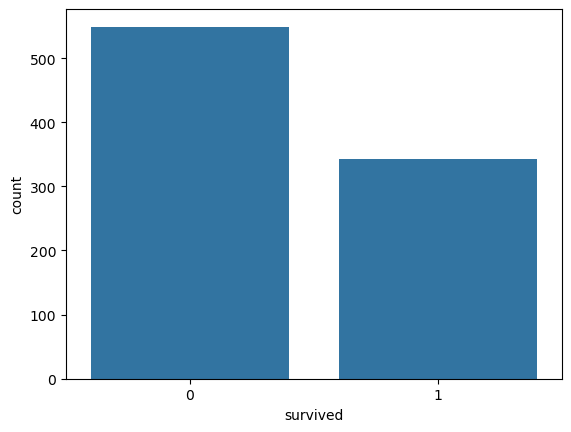

In [78]:
sns.countplot(x= df['survived'],data=df)

<Axes: >

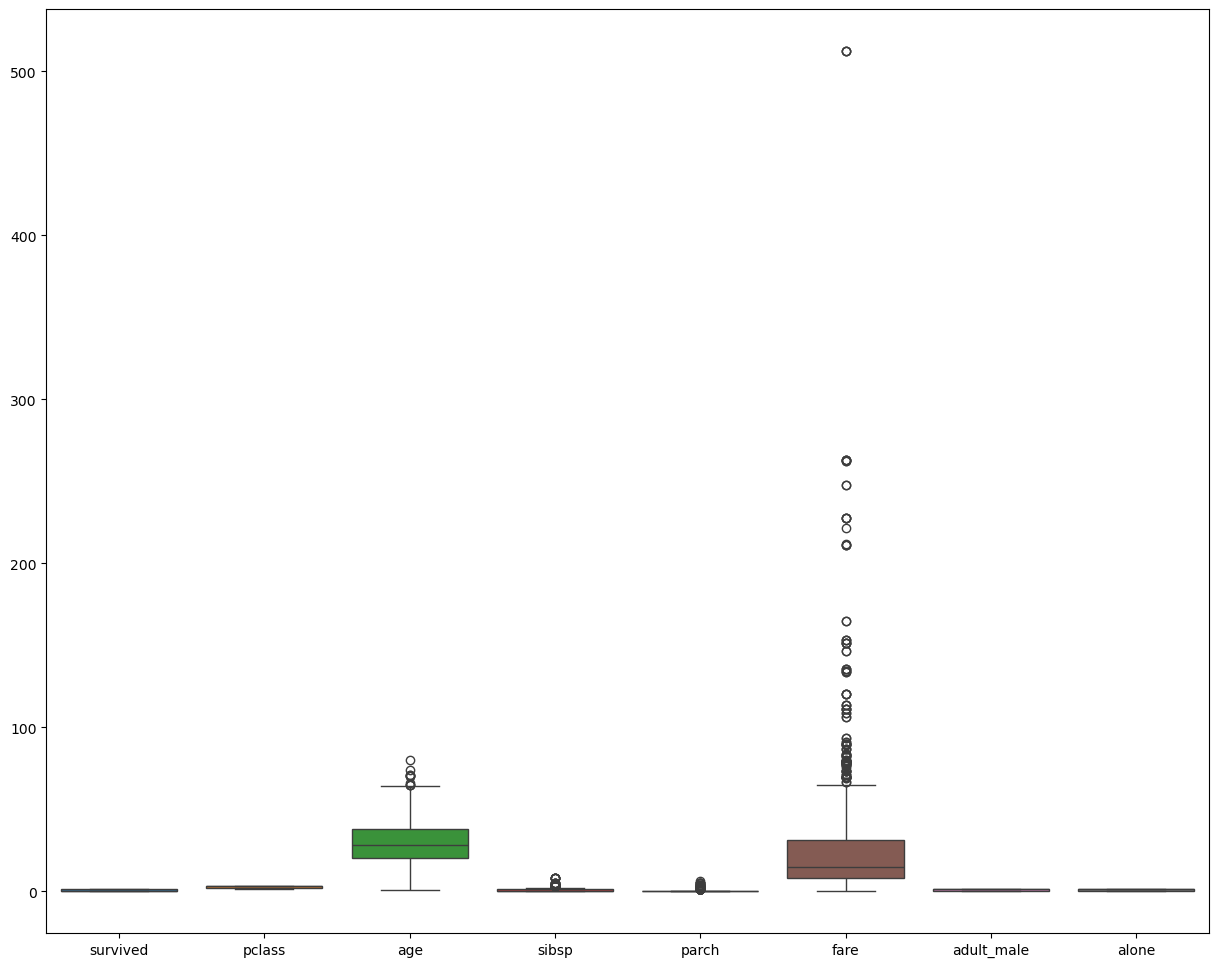

In [79]:
plt.figure(figsize=(15,12))
sns.boxplot(data=df)

In [80]:
df.dropna(subset=["embark_town"], inplace=True)

In [81]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
class            0
who              0
adult_male       0
embark_town      0
alive            0
alone            0
dtype: int64

In [82]:
label_encoders={}
cat_cols=df.select_dtypes(include=["object","category"]).columns
for col in cat_cols:
    df[col]=df[col].astype='string'
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col]=le



In [83]:
label_encoders

{'sex': LabelEncoder(),
 'class': LabelEncoder(),
 'who': LabelEncoder(),
 'embark_town': LabelEncoder(),
 'alive': LabelEncoder()}

<Axes: >

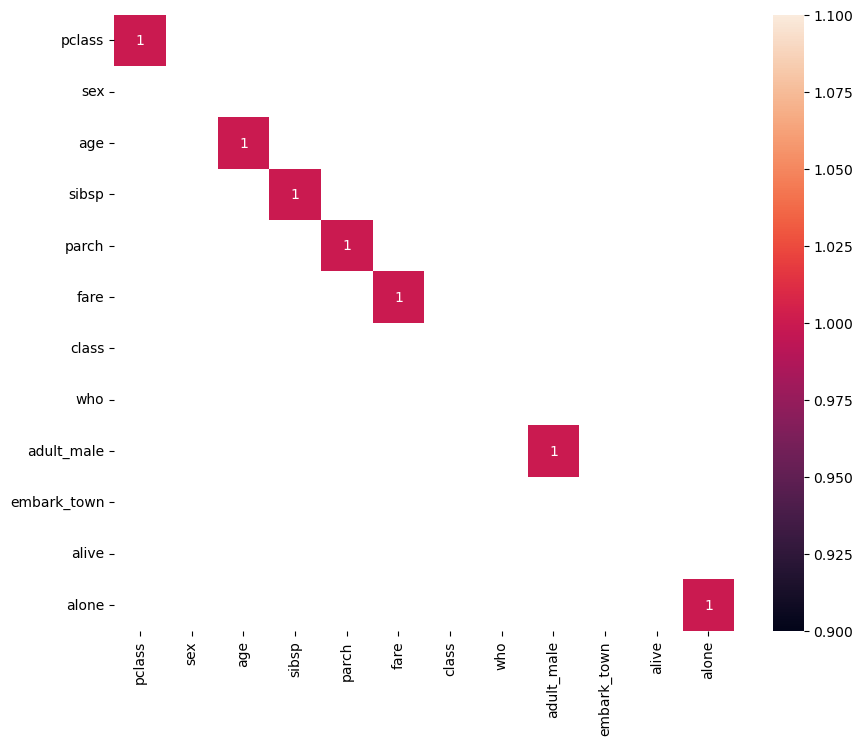

In [84]:
corr=df.drop("survived",axis=1).corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,mask=corr<0.85)


In [85]:
target_col='age'
if df[target_col].isna().sum()>0:
    df_notnull=df[df[target_col].notna()]
    df_null=df[df[target_col].isna()]
    x_train=df_notnull.drop(columns=[target_col])
    y_train=df_notnull[target_col]
    x_pred=df_null.drop(columns=[target_col])
    reg=DecisionTreeRegressor(random_state=42)
    reg.fit(x_train,y_train)
    df.loc[df_null.index,target_col]=reg.predict(x_pred)
    print("missing values after filling = ",df['age'].isna().sum())

missing values after filling =  0
